In [40]:
import numpy as np
import pandas as pd
import random
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import spacy
from nltk.tokenize import sent_tokenize, word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [32]:
text_data=''
fd=open('/big.txt','r')
text_data=fd.read()
fd.close()
text_data=text_data[:10000]
text_data=text_data.lower()

In [33]:
for i in '!@#$~%^&*()_+-=[]{}\|;:",/<>?"\n':
    text_data = text_data.replace(i,' ')
text_data = text_data.replace("'","")

<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:1: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1368/606166946.py:1: SyntaxWarning: invalid escape sequence '\|'
  for i in '!@#$~%^&*()_+-=[]{}\|;:",/<>?"\n':


In [34]:
text_data = text_data.replace('  ',' ')

In [49]:
words=word_tokenize(text_data)
words = [word for word in words if len(word) != 0]              # Removing Null
word_index = {word: i for i, word in enumerate(set(words))}     # Creating Word Index Dictionary
index_word = {word_index[word]:word for word in word_index}     # Creating Index Word Dictionary
sents = [word_tokenize(sent) for sent in sent_tokenize(text_data)]

In [43]:
window_size = 2

features    = []
labels      = []

for sent in sents:
    for i in range(len(sent) - (window_size*2)):
        features.append(sent[i : i + window_size] + sent[i + window_size + 1 : i + window_size*2 + 1])
        labels.append(sent[ i + window_size ])

X_train=[]
for feature in features:
  enc=np.zeros(len(word_index))
  for word in feature:
    enc[word_index[word]]=1
  X_train.append(enc)
X_train = np.array(X_train)

y_train = []

for label in labels:
    enc = np.zeros(len(word_index))
    enc[word_index[label]] = 1
    y_train.append(enc)
y_train = np.array(y_train)

In [44]:
from keras.models import Sequential
from keras.layers import Dense

model=Sequential()
model.add(Dense(100,activation='relu',input_dim=len(word_index)))
model.add(Dense(len(word_index), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

predictions = model.predict(X_train)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0386 - loss: 6.5578
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0659 - loss: 6.1862
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0526 - loss: 5.5690
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0559 - loss: 5.2442
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0786 - loss: 5.0318
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0819 - loss: 4.8348
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1012 - loss: 4.6361
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1385 - loss: 4.4276
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1631 - loss: 4.2064
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1891 - loss: 3.9653
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [45]:
word_embeddings = model.get_weights()[0]

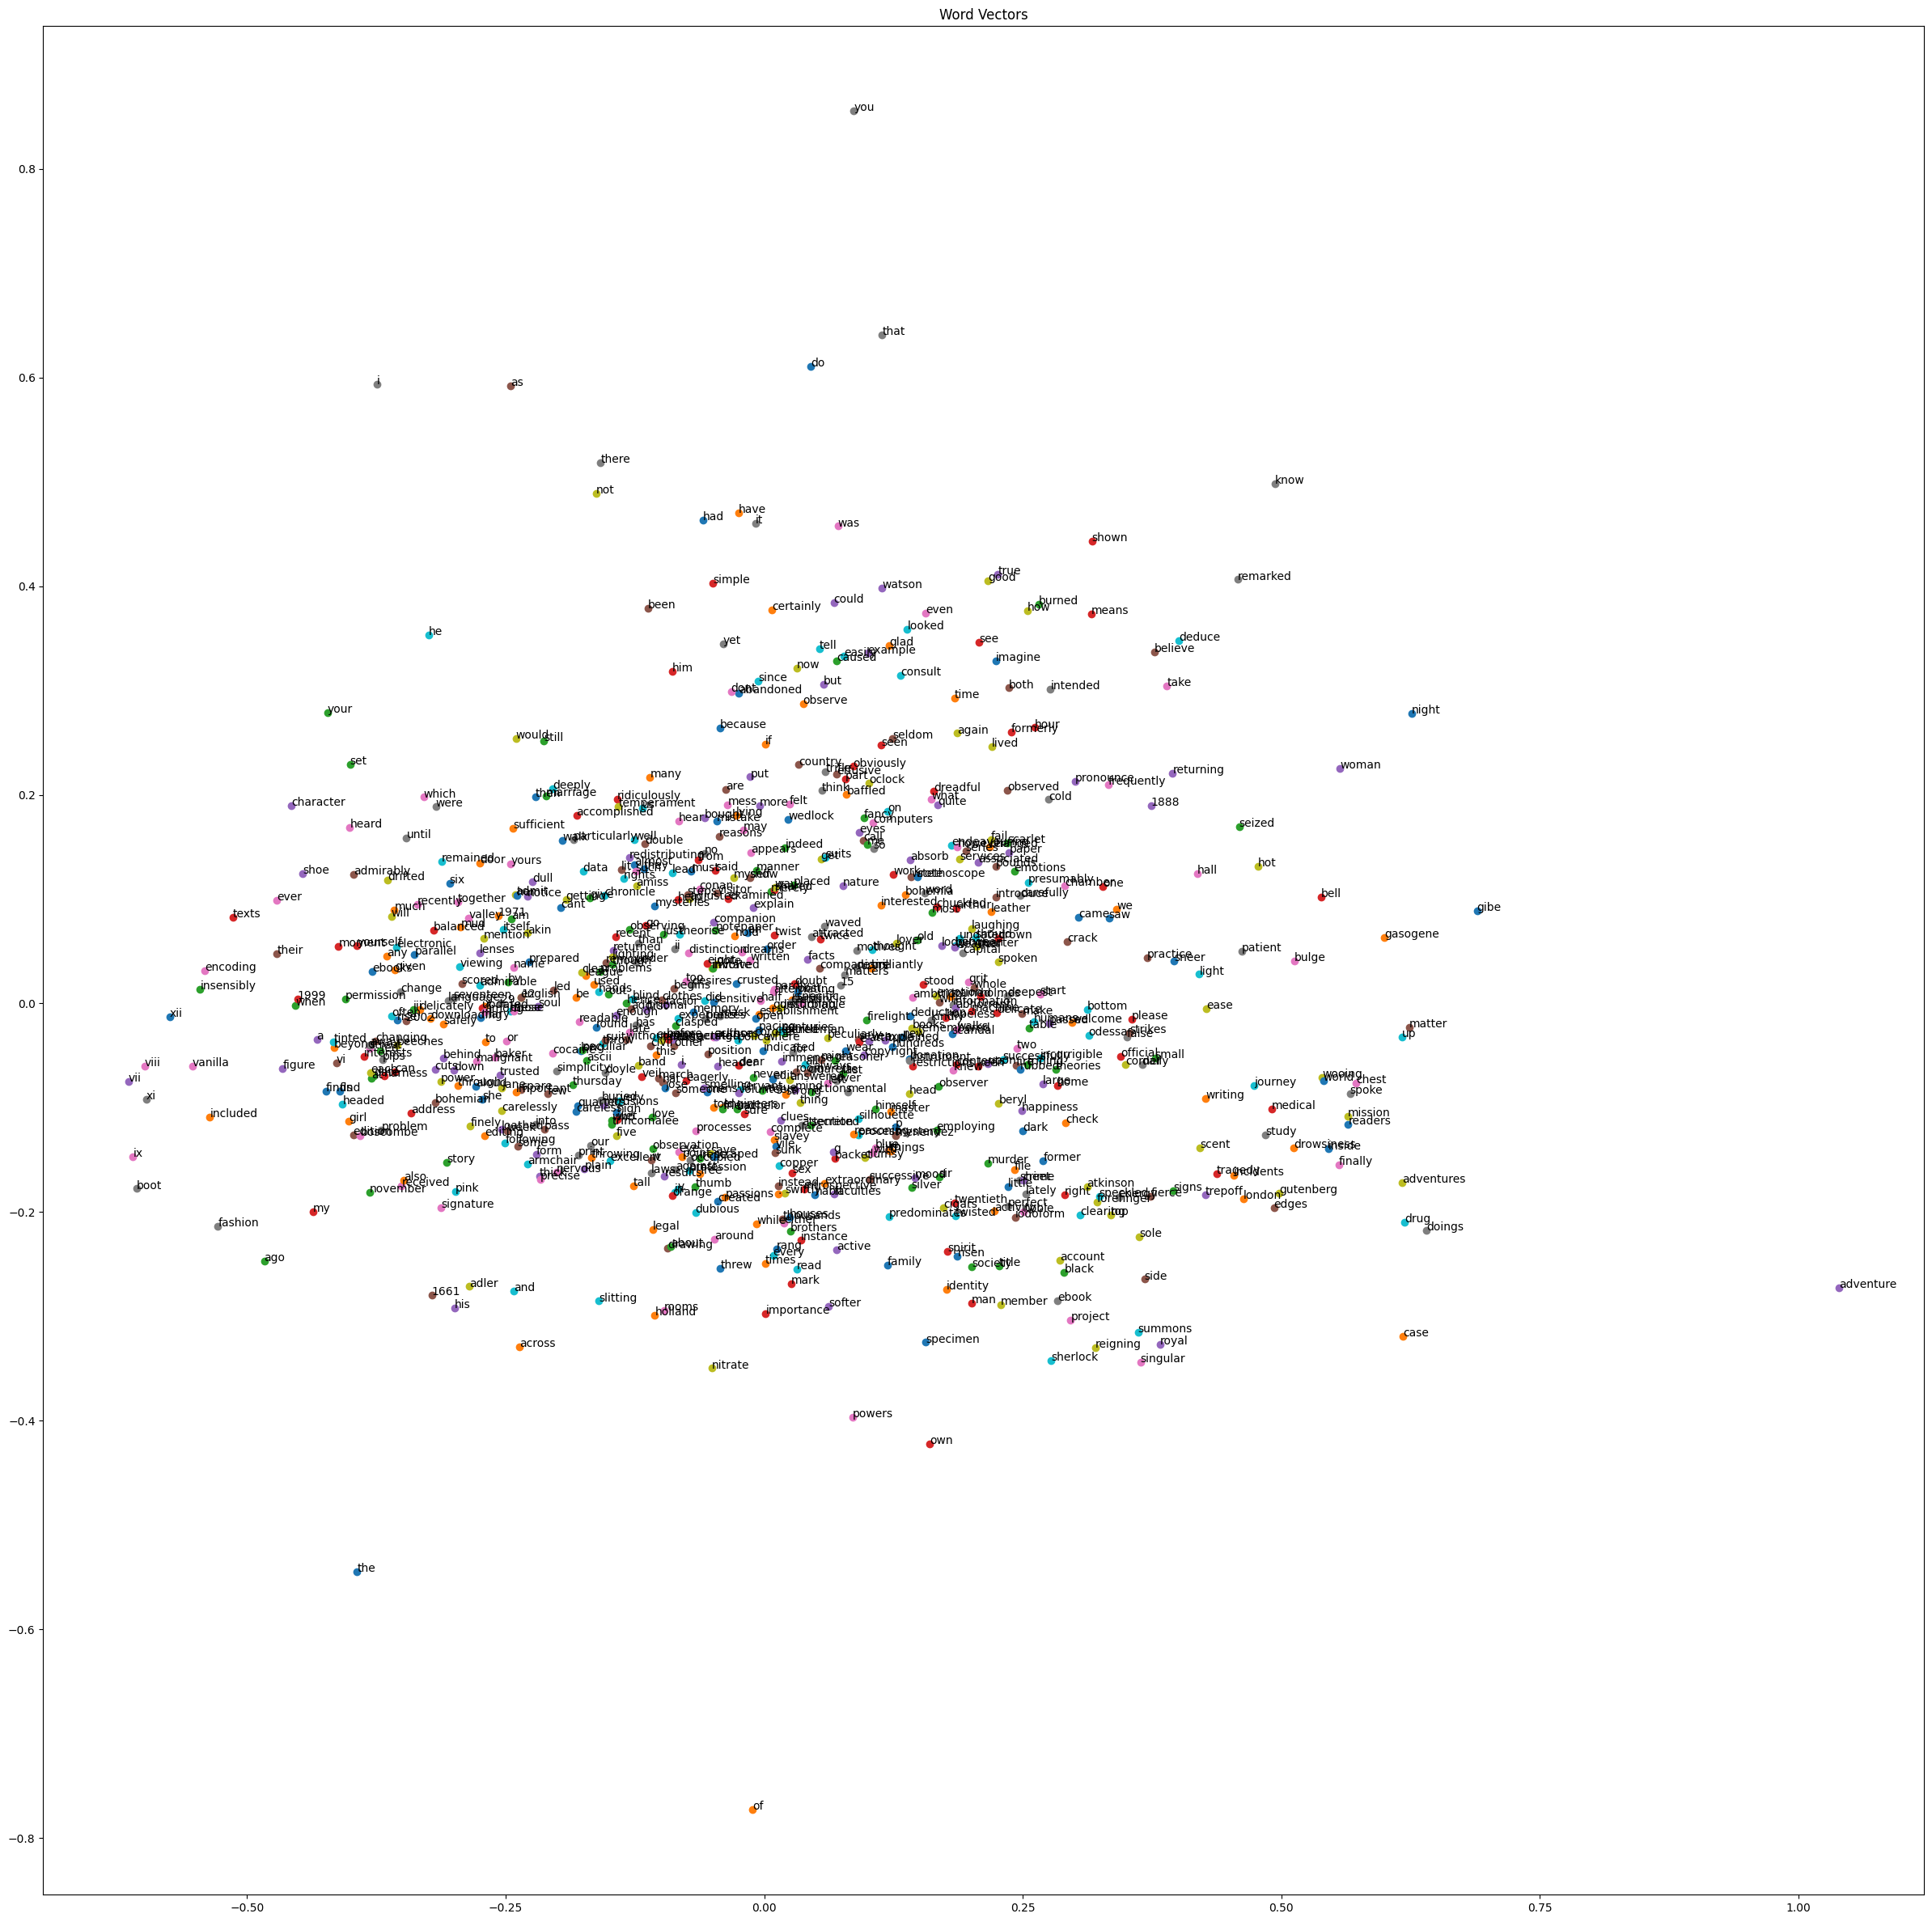

In [52]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sample_words=word_index.keys()

# Get embeddings for sample words
sample_embedding=[]
for word in sample_words:
  idx = word_index[word]
  embedding=word_embeddings[idx]
  sample_embedding.append(embedding)

pca=PCA(n_components=2)
reduce_dim=pca.fit_transform(sample_embedding)

plt.figure(figsize=(30,30))
for i,word in enumerate(sample_words):
  x,y=reduce_dim[i]
  plt.scatter(x,y)
  plt.annotate(word,xy=(x,y))
  plt.title('Word Vectors')
plt.show()

In [51]:
target_word = word_embeddings[word_index['this']]
distances = np.dot(word_embeddings, target_word)
most_similar_indices = np.argsort(distances)[::-1][:10]
most_similar_words = [index_word[i] for i in most_similar_indices]
print("Most similar words to target word:", most_similar_words)

Most similar words to target word: ['this', 'civil', 'redistributing', 'sherlock', 'project', 'viewing', 'other', 'adventure', 'mystery', 'ebook']
